## 1. Import

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score


from sklearn.preprocessing import StandardScaler, LabelEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.feature_selection import SelectKBest, f_classif

import warnings
warnings.filterwarnings('ignore')



## 2. EDA

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

path="/content/drive/MyDrive/ColabNotebooks/Project/Dataset/loan_data.csv"

df=pd.read_csv(path)

print(df.shape)

df.head()

(45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
df.isnull().sum()



,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


loan_status
0    35000
1    10000
Name: count, dtype: int64

Approval Rate: 22.2%
Rejection Rate: 77.8%


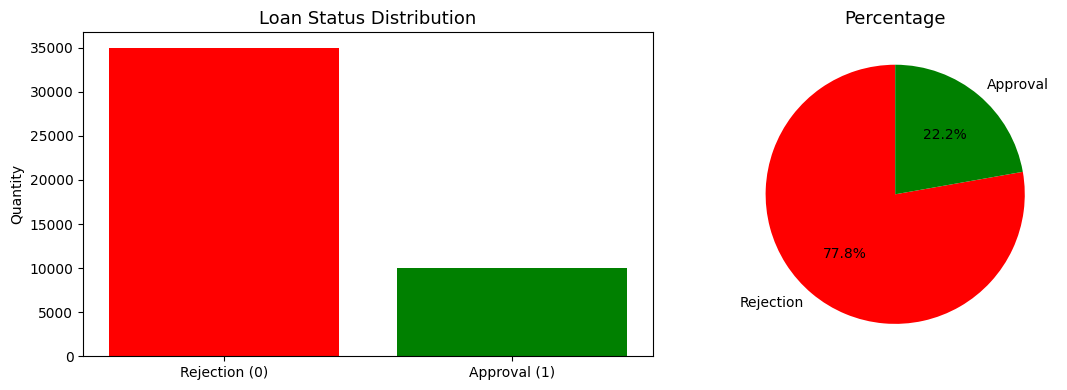

In [ ]:
target_counts = df['loan_status'].value_counts()
print(target_counts)

print(f'\nApproval Rate: {target_counts[1]/len(df)*100:.1f}%')
print(f'Rejection Rate: {target_counts[0]/len(df)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Rejection (0)', 'Approval (1)'], target_counts.values, color=['red', 'green'])
axes[0].set_title('Loan Status Distribution', fontsize=13)
axes[0].set_ylabel('Quantity')



axes[1].pie(target_counts.values, labels=['Rejection', 'Approval'],
            autopct='%1.1f%%', colors=['red', 'green'], startangle=90)
axes[1].set_title('Percentage', fontsize=13)

plt.tight_layout()
plt.show()

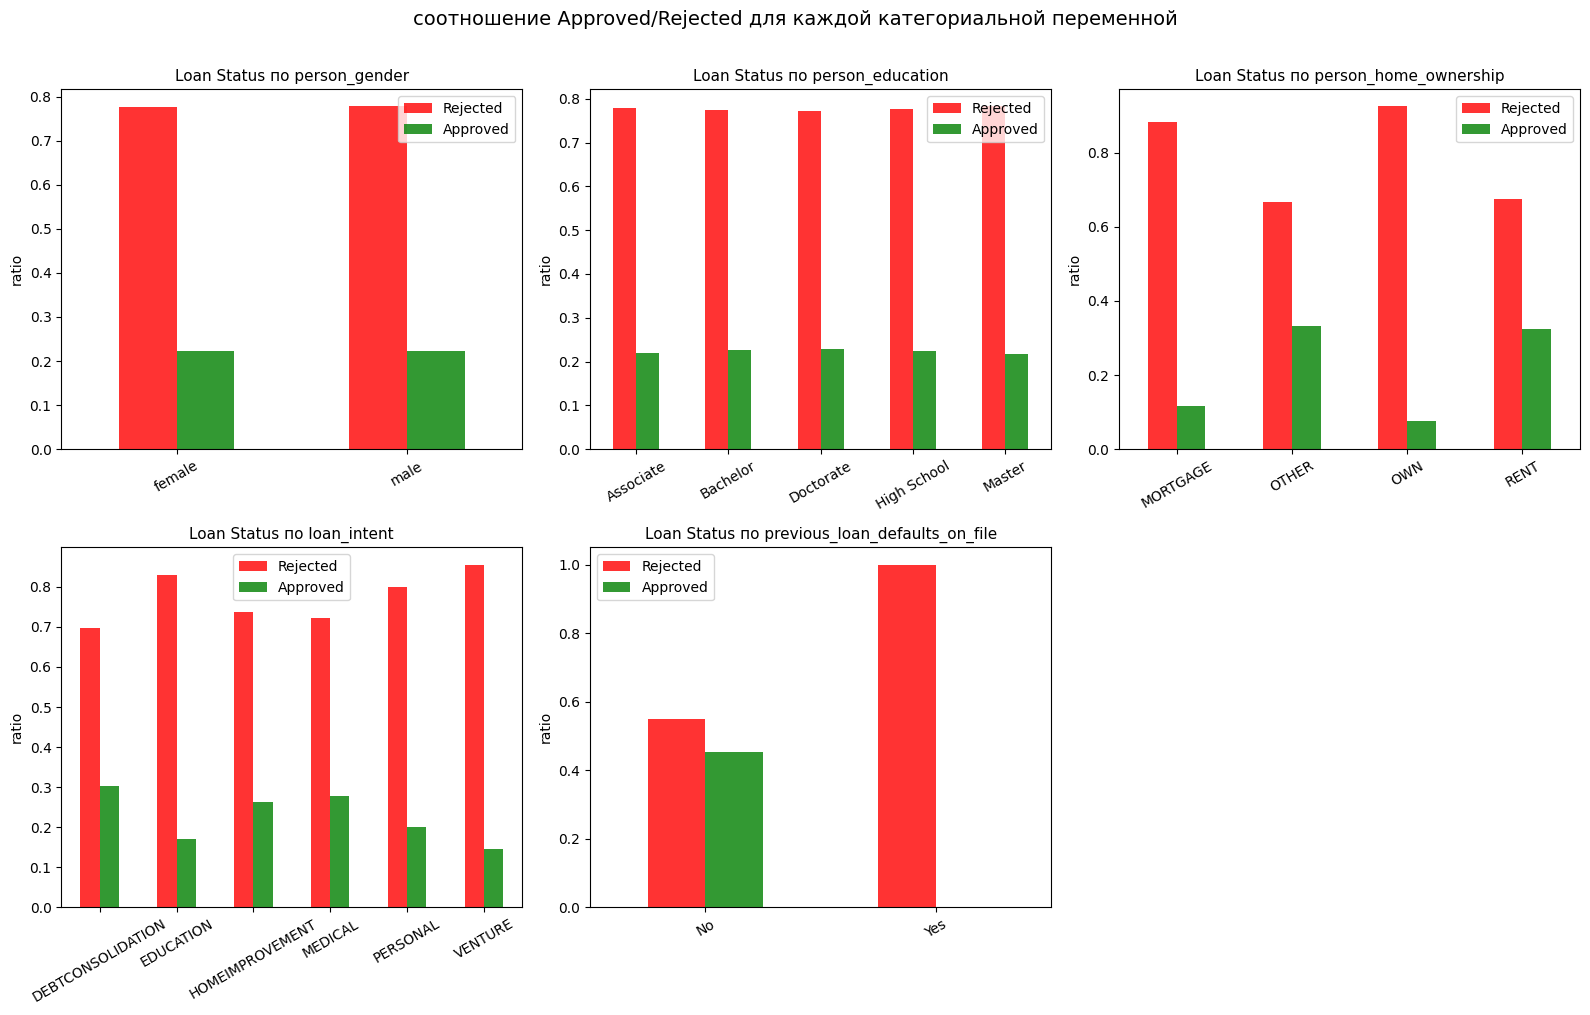

In [ ]:
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership',
                    'loan_intent', 'previous_loan_defaults_on_file']


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()


for i, col in enumerate(categorical_cols):
    counts = df.groupby(col)['loan_status'].value_counts(normalize=True).unstack()


    counts.plot(kind='bar', ax=axes[i], color=['red', 'green'], alpha=0.8)
    axes[i].set_title(f'Loan Status по {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('ratio')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Rejected', 'Approved'])

axes[-1].set_visible(False)

plt.suptitle('соотношение Approved/Rejected для каждой категориальной переменной', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

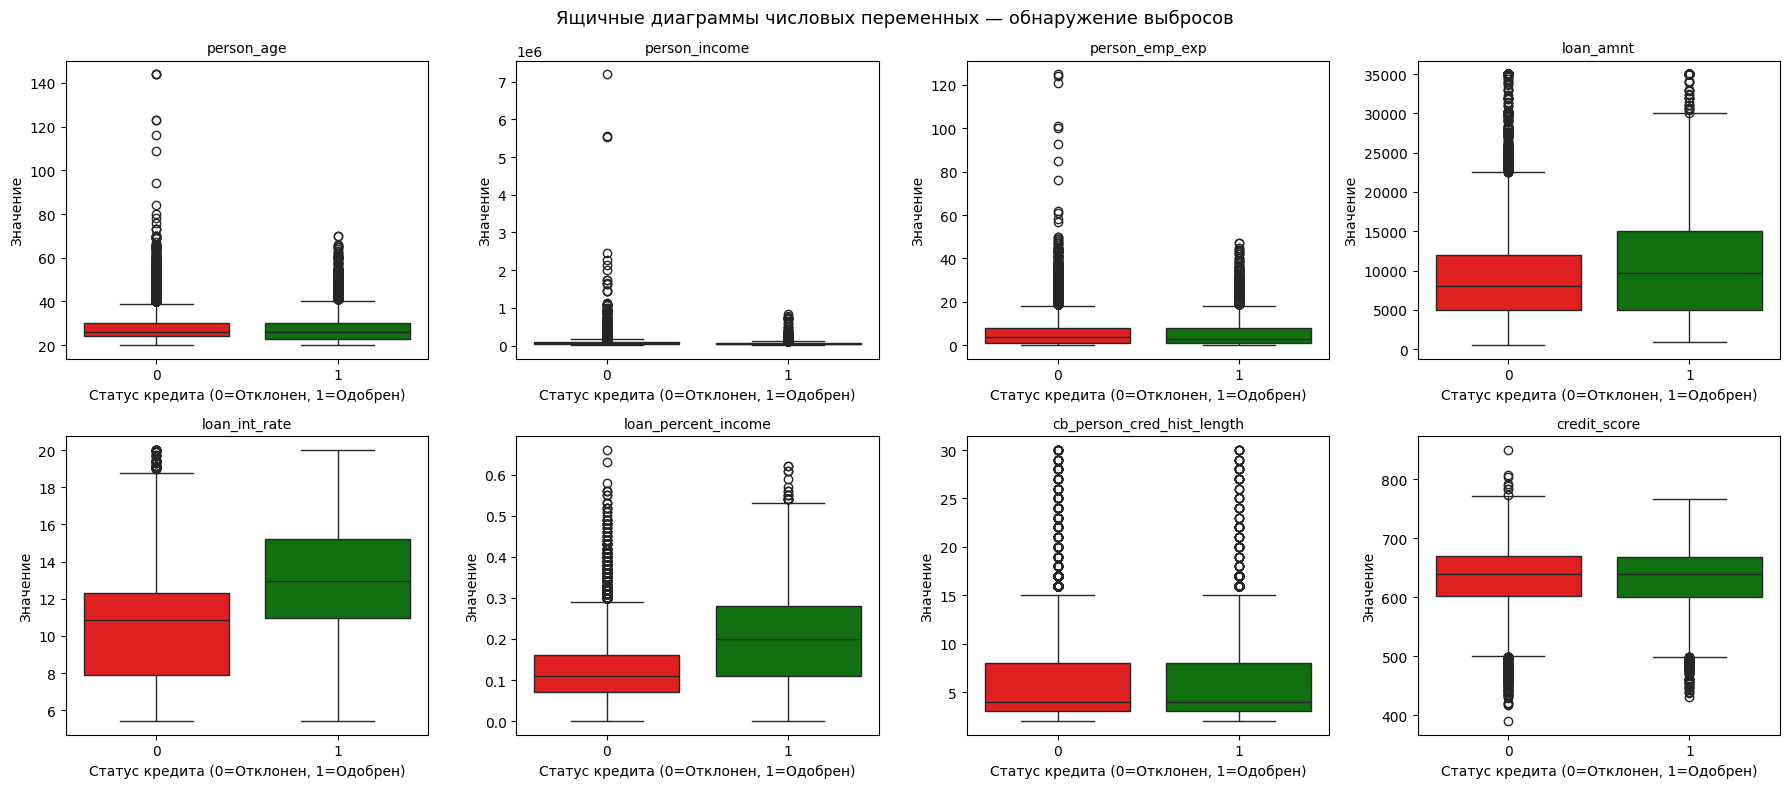

In [ ]:
numeric_cols = ['person_age', 'person_income', 'person_emp_exp',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length', 'credit_score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='loan_status', y=col, data=df, ax=axes[i], palette={'0': 'red', '1': 'green'})
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Статус кредита (0=Отклонен, 1=Одобрен)")
    axes[i].set_ylabel('Значение')

plt.suptitle('Ящичные диаграммы числовых переменных — обнаружение выбросов', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Preprocessing




In [ ]:

df = df[df['person_age'].between(18, 100)]
df = df[df['person_emp_exp'] < df['person_age']]


df = df[df['credit_score'].between(300, 850)]


df = df[df['person_income'] > 0]

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df['person_gender'] = df['person_gender'].map({'male': 1, 'female': 0})

df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})


education_order = {'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4}
df['person_education'] = df['person_education'].map(education_order)


home_ownership_map = {'RENT': 1, 'MORTGAGE': 2, 'OWN': 3, 'OTHER': 4}
df['person_home_ownership'] = df['person_home_ownership'].map(home_ownership_map)

loan_intent_map = {'PERSONAL': 1, 'EDUCATION': 2, 'MEDICAL': 3,
                   'VENTURE': 4, 'HOMEIMPROVEMENT': 5, 'DEBTCONSOLIDATION': 6}
df['loan_intent'] = df['loan_intent'].map(loan_intent_map)


print(df.dtypes)

person_age                        float64
person_gender                       int64
person_education                    int64
person_income                     float64
person_emp_exp                      int64
person_home_ownership               int64
loan_amnt                         float64
loan_intent                         int64
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file      int64
loan_status                         int64
dtype: object


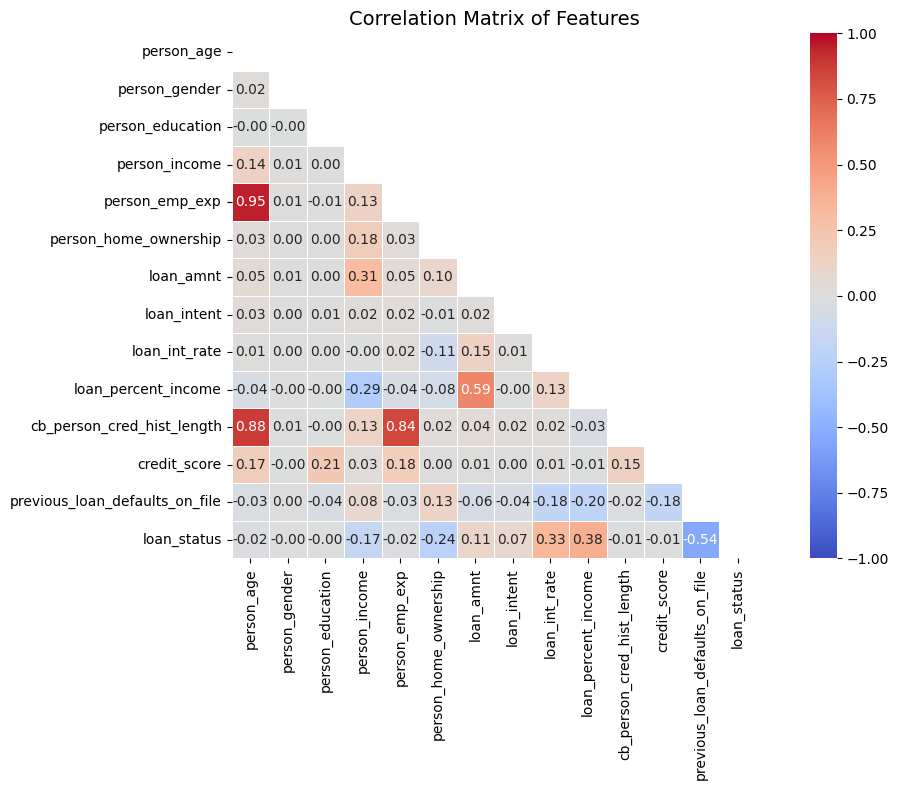

loan_percent_income               0.384873
loan_int_rate                     0.332046
loan_amnt                         0.107725
loan_intent                       0.073576
person_gender                    -0.000534
person_education                 -0.001126
credit_score                     -0.007409
cb_person_cred_hist_length       -0.014733
person_emp_exp                   -0.019529
person_age                       -0.020545
person_income                    -0.169034
person_home_ownership            -0.237793
previous_loan_defaults_on_file   -0.543188


In [ ]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Features', fontsize=14)
plt.tight_layout()
plt.show()


print(correlation_matrix['loan_status'].drop('loan_status').sort_values(ascending=False).to_string())


In [ ]:
X = df.drop(columns=['loan_status'])
Y = df['loan_status']
print(f'Features (X): {X.shape} — {list(X.columns)}')
print(f'Target (Y): {Y.shape} — Распределение: {Y.value_counts().to_dict()}')

Features (X): (44993, 13) — ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Target (Y): (44993,) — Распределение: {0: 34993, 1: 10000}


In [ ]:
selected_features = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'person_home_ownership',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score',
    'previous_loan_defaults_on_file'
]

X_selected = X[selected_features]


print(selected_features)

['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42, stratify=Y
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Training

In [ ]:
print('Training Logistic Regression...')

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver='lbfgs'
)


lr_model.fit(X_train, Y_train)

Y_pred_lr = lr_model.predict(X_test)

Y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print('Logistic Regression training completed!')

Training Logistic Regression...
Logistic Regression training completed!


In [ ]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, Y_train)

Y_pred_rf = rf_model.predict(X_test)
Y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest training completed!')

Training Random Forest...
Random Forest training completed!


In [ ]:
print('Training Gradient Boosting... ')

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    min_samples_split=10,
    random_state=42
)

gb_model.fit(X_train, Y_train)


Y_pred_gb = gb_model.predict(X_test)
Y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print('Gradient Boosting training completed!')

Training Gradient Boosting... 
Gradient Boosting training completed!


## 5. Model Evaluation

In [ ]:
models = {
    'Logistic Regression': (Y_pred_lr, Y_prob_lr),
    'Random Forest':       (Y_pred_rf, Y_prob_rf),
    'Gradient Boosting':   (Y_pred_gb, Y_prob_gb)
}


results = []
for name, (y_pred, y_prob) in models.items():
    acc = accuracy_score(Y_test, y_pred)
    auc = roc_auc_score(Y_test, y_prob)
    report = classification_report(Y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'ROC-AUC': round(auc, 4),
        'Precision (class 1)': round(report['1']['precision'], 4),
        'Recall (class 1)': round(report['1']['recall'], 4),
        'F1-Score (class 1)': round(report['1']['f1-score'], 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print('='*70)
print('Comparison Results of the 3 Models')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n Best Model (by ROC-AUC): {results_df["ROC-AUC"].idxmax()}')

Comparison Results of the 3 Models
                     Accuracy  ROC-AUC  Precision (class 1)  Recall (class 1)  F1-Score (class 1)
Model                                                                                            
Logistic Regression    0.8934   0.9494               0.7679            0.7460              0.7568
Random Forest          0.9203   0.9703               0.8719            0.7520              0.8075
Gradient Boosting      0.9251   0.9747               0.8692            0.7805              0.8224

 Best Model (by ROC-AUC): Gradient Boosting


In [ ]:
for name, (y_pred, y_prob) in models.items():
    print(f'\n{'='*50}')
    print(f'{name}')
    print('='*50)
    print(classification_report(Y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))


Logistic Regression
              precision    recall  f1-score   support

Rejected (0)       0.93      0.94      0.93      6999
Approved (1)       0.77      0.75      0.76      2000

    accuracy                           0.89      8999
   macro avg       0.85      0.84      0.84      8999
weighted avg       0.89      0.89      0.89      8999


Random Forest
              precision    recall  f1-score   support

Rejected (0)       0.93      0.97      0.95      6999
Approved (1)       0.87      0.75      0.81      2000

    accuracy                           0.92      8999
   macro avg       0.90      0.86      0.88      8999
weighted avg       0.92      0.92      0.92      8999


Gradient Boosting
              precision    recall  f1-score   support

Rejected (0)       0.94      0.97      0.95      6999
Approved (1)       0.87      0.78      0.82      2000

    accuracy                           0.93      8999
   macro avg       0.90      0.87      0.89      8999
weighted avg       

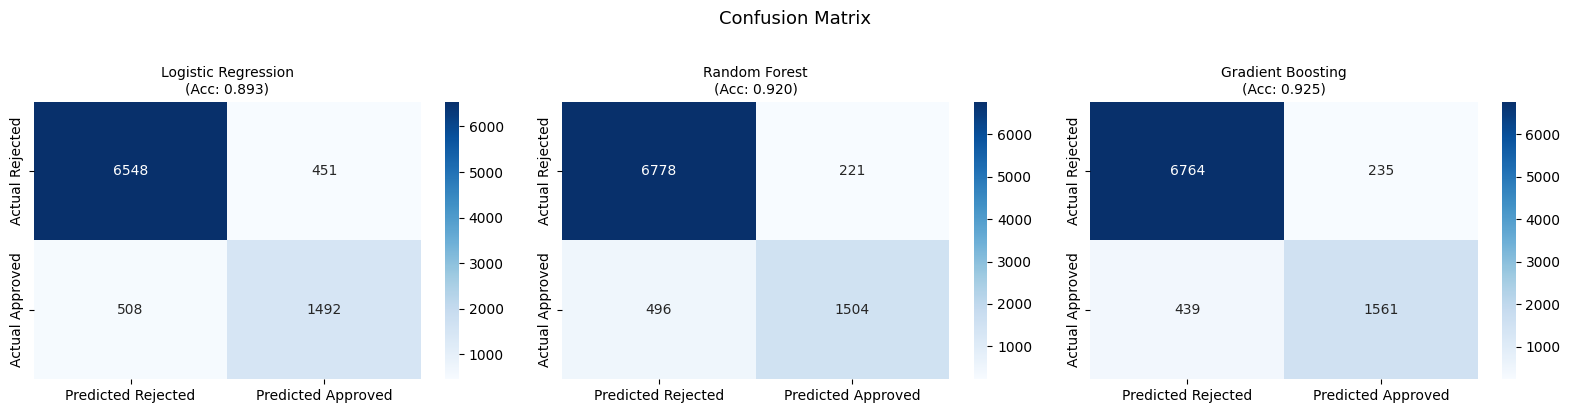

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(Y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted Rejected', 'Predicted Approved'],
                yticklabels=['Actual Rejected', 'Actual Approved'])
    ax.set_title(f'{name}\n(Acc: {accuracy_score(Y_test, y_pred):.3f})', fontsize=10)

plt.suptitle('Confusion Matrix', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

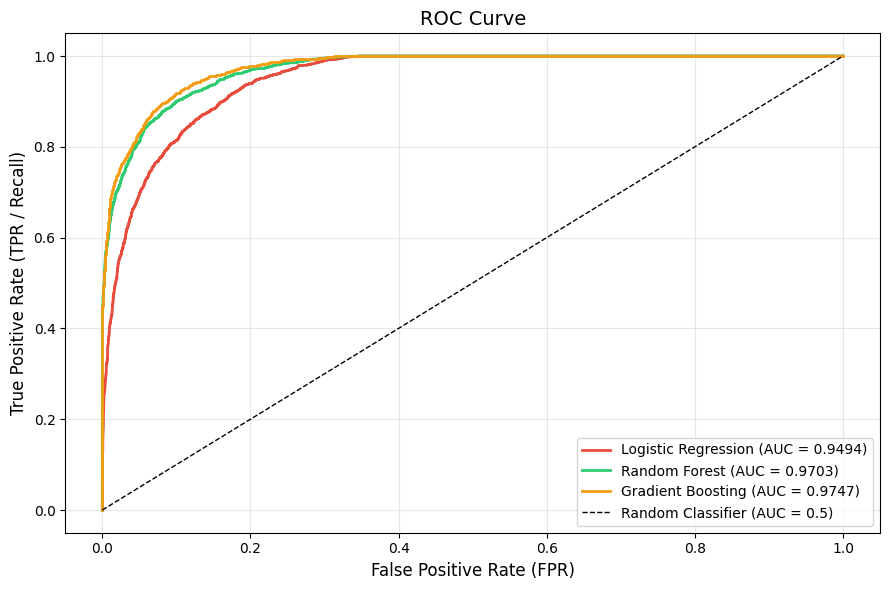

In [ ]:

plt.figure(figsize=(9, 6))

colors = {'Logistic Regression': '#e74c3c', 'Random Forest': '#2ecc71', 'Gradient Boosting': '#f39c12'}

for name, (_, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(Y_test, y_prob)


    auc = roc_auc_score(Y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 6. Select the best model and save the file.

In [ ]:
auc_scores = {
    'Logistic Regression': roc_auc_score(Y_test, Y_prob_lr),
    'Random Forest':       roc_auc_score(Y_test, Y_prob_rf),
    'Gradient Boosting':   roc_auc_score(Y_test, Y_prob_gb)
}

best_model_name = max(auc_scores, key=auc_scores.get)

best_model_obj = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'Gradient Boosting':   gb_model
}[best_model_name]

for name, auc in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    marker = 'best model:' if name == best_model_name else '  '
    print(f'{marker} {name}: AUC = {auc:.4f}')

best model: Gradient Boosting: AUC = 0.9747
   Random Forest: AUC = 0.9703
   Logistic Regression: AUC = 0.9494


In [ ]:

from google.colab import files
import pickle

model_package = {
    'model': best_model_obj,
    'scaler': scaler,
    'features': selected_features,
    'model_name': best_model_name
}



files.download('best_loan_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(selected_features)

['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
